In [ ]:
# =============================================================================
# MANet Stroke Segmentation - Optimized for Kaggle + Checkpoint / Cache
# Dataset: İNME VERİ SETİ (Stroke Dataset)
#
# CÁCH RESUME KHI BỊ LỖI GIỮA CHỪNG:
#   - Mọi bước nặng đều tự động bỏ qua nếu cache đã tồn tại.
#   - Training tự resume từ epoch cuối cùng đã lưu.
#   - Chỉ cần chạy lại từ đầu; các cell đã xong sẽ skip ngay lập tức.
# =============================================================================

In [4]:
# ============================================================
# CELL 1: Cài đặt thư viện - Fix numpy/pylibjpeg conflict
# ============================================================
import subprocess, sys

def pip(*args):
    result = subprocess.run(
        [sys.executable, "-m", "pip"] + list(args),
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("STDERR:", result.stderr[-1000:])
        raise RuntimeError(f"pip failed: {' '.join(args)}")

# 1. Gỡ các package xung đột
pip("uninstall", "-y", "pydicom", "pylibjpeg", "pylibjpeg-libjpeg", "python-gdcm")

# 2. Cài pydicom không có JPEG decoder (dùng gdcm thay thế)
pip("install", "-q", "--no-deps", "pydicom==2.4.3")

# 3. Cài pylibjpeg 2.x + libjpeg mới nhất (tương thích numpy 2.x)
pip("install", "-q", "pylibjpeg==2.1.0", "pylibjpeg-libjpeg==2.4.0")

# 4. Cài gdcm (fallback decoder cho DICOM)  
pip("install", "-q", "python-gdcm==3.0.24.1")

# 5. Cài các thư viện còn lại
pip("install", "-q", "albumentations", "segmentation-models-pytorch")

print("✅ Cài xong. Restart kernel...")
import IPython
IPython.Application.instance().kernel.do_shutdown(restart=True)

✅ Cài xong. Restart kernel...


{'status': 'ok', 'restart': True}

In [1]:
# ============================================================
# CELL 2: Imports
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import os
import cv2
import pickle
import pydicom
# matplotlib.use("Agg") # Bỏ dòng này để hiển thị ảnh inline trên Kaggle Notebook
import matplotlib.pyplot as plt
import numpy as np
import random
import seaborn as sns

from glob import glob
from tqdm import tqdm
from collections import Counter
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.optim as optim
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True  # Tăng tốc convolution cố định input size

In [2]:
# ============================================================
# CELL 3: Config & đường dẫn cache
# ============================================================
BASE_PATH     = "/kaggle/input/datasets/orvile/inme-veri-seti-stroke-dataset/İNME VERİ SETİ"
WORK_DIR      = "/kaggle/working"
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE      = 256
BATCH_SIZE    = 64  # T4x2: tăng từ 32→64 để tận dụng 2 GPU (16GB x2)
EPOCHS        = 60
FROZEN_EPOCHS = 15
LR_STAGE_1    = 1e-4
LR_STAGE_2    = 1e-5

# Đường dẫn lưu file
CACHE_SPLITS       = os.path.join(WORK_DIR, "cache_data_splits.pkl")   # train/val/test lists
CHECKPOINT_PATH    = os.path.join(WORK_DIR, "checkpoint_latest.pth")   # checkpoint mỗi epoch
BEST_MODEL_PATH    = os.path.join(WORK_DIR, "best_manet_model.pth")    # model tốt nhất

print(f"Device : {DEVICE}")
print(f"WorkDir: {WORK_DIR}")

Device : cuda
WorkDir: /kaggle/working


In [3]:
# ============================================================
# CELL 4: Dataset Exploration
# ============================================================
def explore_dataset_structure(base_path=BASE_PATH):
    print("DATASET STRUCTURE EXPLORATION")
    print("=" * 50)
    if not os.path.exists(base_path):
        print(f"[WARNING] Path not found: {base_path}")
        return
    for root, dirs, files in os.walk(base_path):
        level  = root.replace(base_path, "").count(os.sep)
        indent = " " * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        sub_indent = " " * 2 * (level + 1)
        for f in files[:3]:
            print(f"{sub_indent}{f}")
        if len(files) > 3:
            print(f"{sub_indent}... and {len(files) - 3} more files")

explore_dataset_structure()

DATASET STRUCTURE EXPLORATION
İNME VERİ SETİ/
  Bilgi.xlsx
  248-258.pdf
  İnme Yok/
    11396.png
    14260.png
    13412.png
    ... and 4548 more files
  Kanama/
    DICOM/
      16020.dcm
      10522.dcm
      14851.dcm
      ... and 1090 more files
    OVERLAY/
      16020.png
      12684.png
      13159.png
      ... and 1090 more files
    PNG/
      16020.png
      12684.png
      13159.png
      ... and 1090 more files
  YarısmaVeriSeti_2_Oturum/
    DICOM/
      11328.dcm
      12137.dcm
      14351.dcm
      ... and 97 more files
    OVERLAY/
      14750.png
      12508.png
      14715.png
      ... and 97 more files
    MASKS/
      14750.png
      12508.png
      14715.png
      ... and 97 more files
    PNG/
      14750.png
      12508.png
      14715.png
      ... and 94 more files
  İskemi/
    DICOM/
      15633.dcm
      12070.dcm
      14644.dcm
      ... and 1127 more files
    OVERLAY/
      14127.png
      14325.png
      15055.png
      ... and 1127 more files
  


DATASET COMPOSITION
  Normal (Không đột quỵ): 4,551 (67.2%)
  Ischemic (Thiếu máu cục bộ): 1,130 (16.7%)
  Bleeding (Xuất huyết não): 1,093 (16.1%)
  Total: 6,774


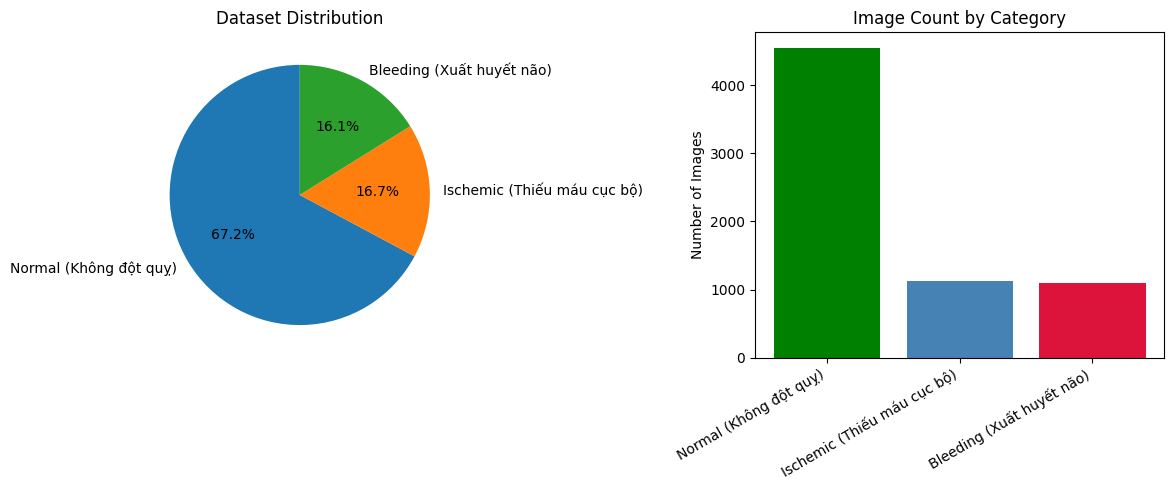

In [4]:
# ============================================================
# CELL 5: Dataset Composition Analysis
# ============================================================
def analyze_dataset(base_path=BASE_PATH):
    categories = {
        "Normal (Không đột quỵ)":     os.path.join(base_path, "İnme Yok"),
        "Ischemic (Thiếu máu cục bộ)":os.path.join(base_path, "İskemi", "PNG"),
        "Bleeding (Xuất huyết não)":  os.path.join(base_path, "Kanama", "PNG"),
    }
    counts = {}
    for cat, path in categories.items():
        if os.path.exists(path):
            counts[cat] = len([f for f in os.listdir(path) if f.lower().endswith(".png")])
        else:
            counts[cat] = 0
            print(f"[WARNING] Path not found: {path}")

    total = sum(counts.values()) or 1
    print("\nDATASET COMPOSITION")
    print("=" * 40)
    for cat, cnt in counts.items():
        print(f"  {cat}: {cnt:,} ({cnt/total*100:.1f}%)")
    print(f"  Total: {total:,}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    labels, values  = list(counts.keys()), list(counts.values())
    ax1.pie(values, labels=labels, autopct="%1.1f%%", startangle=90)
    ax1.set_title("Dataset Distribution")
    ax2.bar(range(len(labels)), values, color=["green", "steelblue", "crimson"])
    ax2.set_xticks(range(len(labels)))
    ax2.set_xticklabels(labels, rotation=30, ha="right")
    ax2.set_title("Image Count by Category")
    ax2.set_ylabel("Number of Images")
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, "dataset_distribution.png"), dpi=100)
    plt.show()
    return counts

dataset_stats = analyze_dataset()

In [5]:
# ============================================================
# CELL 6: Image Loading Utilities
# ============================================================
def load_png(path):
    return cv2.imread(path, cv2.IMREAD_GRAYSCALE)

def load_overlay(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None else None

def load_dicom(path):
    try:
        return pydicom.dcmread(path).pixel_array
    except Exception:
        return None

_test_dcm = glob(f"{BASE_PATH}/İskemi/DICOM/*.dcm")
if _test_dcm:
    _arr = load_dicom(_test_dcm[0])
    print(f"DICOM test OK – shape: {_arr.shape if _arr is not None else 'None'}")

DICOM test OK – shape: (512, 512)


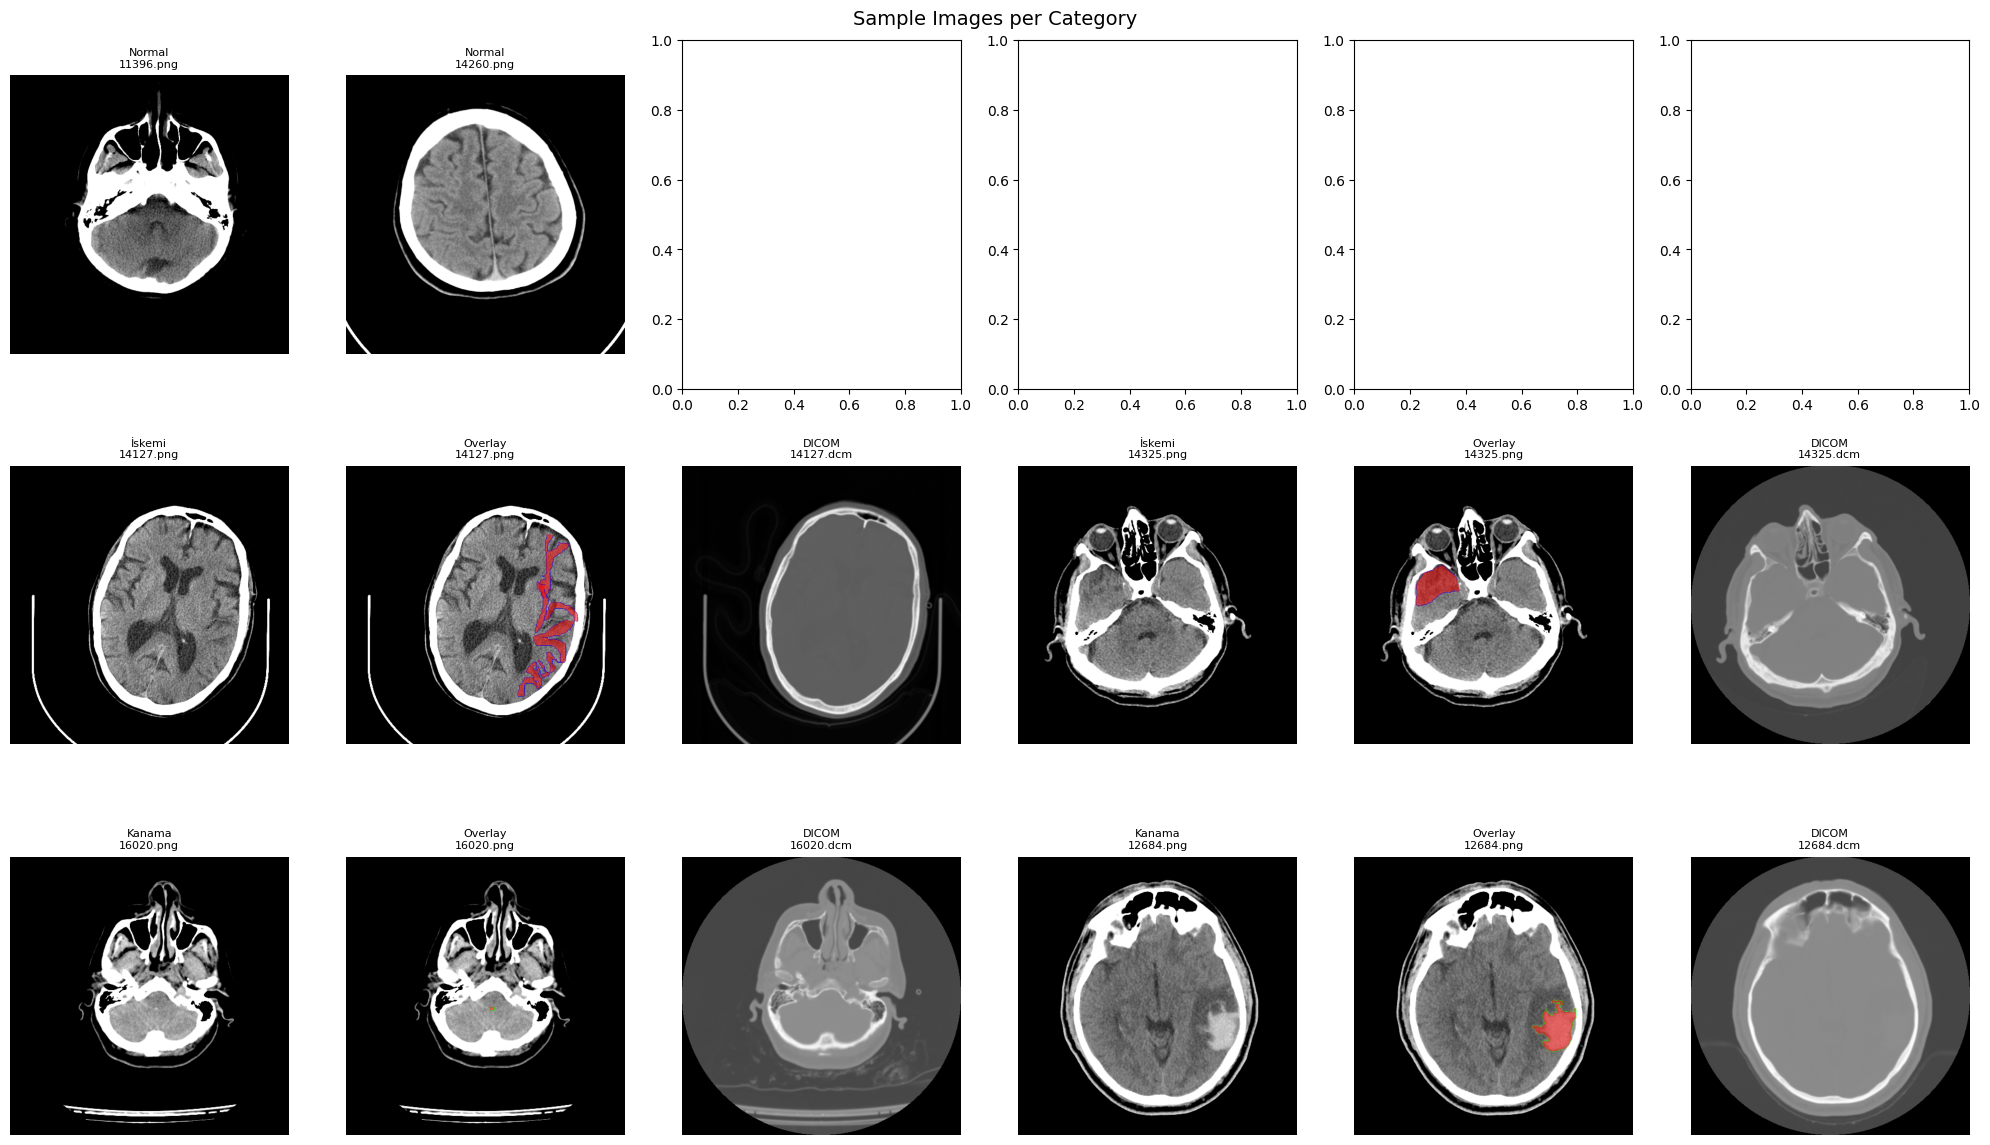

Saved: sample_images.png


In [6]:
# ============================================================
# CELL 7: Visualize Sample Images
# ============================================================
def visualize_category(ax_row, base_path, category_name):
    png_path     = os.path.join(base_path, category_name, "PNG")
    overlay_path = os.path.join(base_path, category_name, "OVERLAY")
    dicom_path   = os.path.join(base_path, category_name, "DICOM")
    if not os.path.exists(png_path):
        return
    png_files = [f for f in os.listdir(png_path) if f.lower().endswith(".png")][:2]
    for idx, filename in enumerate(png_files):
        col = idx * 3
        img = load_png(os.path.join(png_path, filename))
        if img is not None:
            ax_row[col].imshow(img, cmap="gray")
            ax_row[col].set_title(f"{category_name}\n{filename}", fontsize=8)
        ax_row[col].axis("off")
        overlay_file = os.path.join(overlay_path, filename)
        if os.path.exists(overlay_file):
            ov = load_overlay(overlay_file)
            if ov is not None:
                ax_row[col+1].imshow(ov)
                ax_row[col+1].set_title(f"Overlay\n{filename}", fontsize=8)
        ax_row[col+1].axis("off")
        dcm_file = os.path.join(dicom_path, filename.replace(".png", ".dcm"))
        if os.path.exists(dcm_file):
            dcm_img = load_dicom(dcm_file)
            if dcm_img is not None:
                ax_row[col+2].imshow(dcm_img, cmap="gray")
                ax_row[col+2].set_title(f"DICOM\n{filename.replace('.png','.dcm')}", fontsize=8)
        ax_row[col+2].axis("off")

def visualize_samples(base_path=BASE_PATH):
    fig, axes = plt.subplots(3, 6, figsize=(20, 12))
    plt.suptitle("Sample Images per Category", fontsize=14)
    normal_path = os.path.join(base_path, "İnme Yok")
    if os.path.exists(normal_path):
        normal_files = [f for f in os.listdir(normal_path) if f.lower().endswith(".png")][:2]
        for i, fn in enumerate(normal_files):
            img = load_png(os.path.join(normal_path, fn))
            if img is not None:
                axes[0, i].imshow(img, cmap="gray")
                axes[0, i].set_title(f"Normal\n{fn}", fontsize=8)
            axes[0, i].axis("off")
    visualize_category(axes[1], base_path, "İskemi")
    visualize_category(axes[2], base_path, "Kanama")
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, "sample_images.png"), dpi=100)
    plt.show()
    print("Saved: sample_images.png")

visualize_samples()

In [7]:
# ============================================================
# CELL 8: Prepare Dataset
# ============================================================
def prepare_dataset(base_path=BASE_PATH, include_competition=True):
    """Labels: 0=Normal · 1=Ischemic · 2=Bleeding"""
    dataset      = []
    class_to_idx = {"Normal": 0, "Ischemic": 1, "Bleeding": 2}

    # 1. Normal
    normal_dir = os.path.join(base_path, "İnme Yok")
    for img_file in sorted(glob(f"{normal_dir}/*.png")):
        dataset.append({"image": img_file, "mask": None,
                         "label": 0, "is_dicom": False, "use_direct_mask": False})

    # 2. Ischemic
    iskemi_dir = os.path.join(base_path, "İskemi")
    for img_file in sorted(glob(f"{iskemi_dir}/PNG/*.png")):
        fn = os.path.basename(img_file)
        mf = os.path.join(iskemi_dir, "OVERLAY", fn)
        dataset.append({"image": img_file, "mask": mf if os.path.exists(mf) else None,
                         "label": 1, "is_dicom": False, "use_direct_mask": False})
    for dcm_file in sorted(glob(f"{iskemi_dir}/DICOM/*.dcm")):
        fn = os.path.basename(dcm_file).replace(".dcm", ".png")
        mf = os.path.join(iskemi_dir, "OVERLAY", fn)
        dataset.append({"image": dcm_file, "mask": mf if os.path.exists(mf) else None,
                         "label": 1, "is_dicom": True, "use_direct_mask": False})

    # 3. Hemorrhagic
    kanama_dir = os.path.join(base_path, "Kanama")
    for img_file in sorted(glob(f"{kanama_dir}/PNG/*.png")):
        fn = os.path.basename(img_file)
        mf = os.path.join(kanama_dir, "OVERLAY", fn)
        dataset.append({"image": img_file, "mask": mf if os.path.exists(mf) else None,
                         "label": 2, "is_dicom": False, "use_direct_mask": False})
    for dcm_file in sorted(glob(f"{kanama_dir}/DICOM/*.dcm")):
        fn = os.path.basename(dcm_file).replace(".dcm", ".png")
        mf = os.path.join(kanama_dir, "OVERLAY", fn)
        dataset.append({"image": dcm_file, "mask": mf if os.path.exists(mf) else None,
                         "label": 2, "is_dicom": True, "use_direct_mask": False})

    # 4. Competition data
    if include_competition:
        existing_ids = {os.path.splitext(os.path.basename(d["image"]))[0] for d in dataset}

        s1_dir      = os.path.join(base_path, "YarısmaVeriSeti_1_Oturum")
        answer_file = os.path.join(s1_dir, "ASAMA1_Cevaplar.txt")
        if os.path.exists(answer_file):
            s1_labels = {}
            with open(answer_file, "r", encoding="utf-8") as fh:
                for line in fh:
                    parts = line.strip().split("\t")
                    if len(parts) == 2 and parts[0].strip().isdigit():
                        s1_labels[parts[0].strip()] = int(parts[1].strip())
            s1_added = 0
            for img_id, lbl in s1_labels.items():
                if img_id in existing_ids:
                    continue
                png_file  = os.path.join(s1_dir, "PNG",   f"{img_id}.png")
                mask_file = os.path.join(s1_dir, "MASKS", f"{img_id}.png")
                if not os.path.exists(png_file):
                    continue
                if lbl == 0:
                    dataset.append({"image": png_file, "mask": None,
                                     "label": 0, "is_dicom": False, "use_direct_mask": False})
                else:
                    dataset.append({"image": png_file,
                                     "mask": mask_file if os.path.exists(mask_file) else None,
                                     "label": 1, "is_dicom": False, "use_direct_mask": True})
                s1_added += 1
            print(f"[Competition] Session 1: +{s1_added} images")

        s2_dir     = os.path.join(base_path, "YarısmaVeriSeti_2_Oturum")
        s2_png_dir = os.path.join(s2_dir, "PNG")
        if os.path.exists(s2_png_dir):
            s2_added = 0
            for png_file in sorted(glob(f"{s2_png_dir}/*.png")):
                img_id = os.path.splitext(os.path.basename(png_file))[0]
                if img_id in existing_ids:
                    continue
                mask_file  = os.path.join(s2_dir, "MASKS", f"{img_id}.png")
                has_lesion = os.path.exists(mask_file) and os.path.getsize(mask_file) > 1000
                dataset.append({"image": png_file,
                                 "mask": mask_file if has_lesion else None,
                                 "label": 1 if has_lesion else 0,
                                 "is_dicom": False, "use_direct_mask": has_lesion})
                s2_added += 1
            print(f"[Competition] Session 2: +{s2_added} images")

    print(f"\n[Summary] Total: {len(dataset)} | "
          f"Normal={sum(1 for d in dataset if d['label']==0)} | "
          f"Ischemic={sum(1 for d in dataset if d['label']==1)} | "
          f"Bleeding={sum(1 for d in dataset if d['label']==2)}")
    return dataset, class_to_idx

In [8]:
# ============================================================
# CELL 9: Image Processing Utilities
# ============================================================
def get_hu_image(ds):
    img       = ds.pixel_array.astype(np.float32)
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    slope     = float(getattr(ds, "RescaleSlope",     1))
    return img * slope + intercept

def apply_windowing(hu_image, center, width):
    lo = center - width / 2
    hi = center + width / 2
    windowed = np.clip(hu_image, lo, hi)
    return ((windowed - lo) / (hi - lo) * 255.0).astype(np.uint8)

def extract_mask_from_overlay(overlay_path, target_size=(IMG_SIZE, IMG_SIZE)):
    overlay = cv2.imread(overlay_path)
    if overlay is None:
        return np.zeros(target_size, dtype=np.float32)
    overlay = cv2.resize(overlay, target_size)
    r = overlay[:, :, 2].astype(np.int16)
    g = overlay[:, :, 1].astype(np.int16)
    b = overlay[:, :, 0].astype(np.int16)
    return ((r > 100) & (r > g + 40) & (r > b + 40)).astype(np.float32)

In [9]:
# ============================================================
# CELL 10: PyTorch Dataset
# ============================================================
class CTScanDataset(Dataset):
    def __init__(self, data, augment=False):
        self.data = data
        aug = [
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.02, scale_limit=0.1, rotate_limit=10, p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.Normalize(mean=(0.0,), std=(1.0,)),
            ToTensorV2(),
        ]
        base = [A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(mean=(0.0,), std=(1.0,)), ToTensorV2()]
        self.transform = A.Compose(aug if augment else base)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        entry    = self.data[idx]
        img_path = entry["image"]

        if entry.get("is_dicom", False):
            try:
                ds     = pydicom.dcmread(img_path)
                hu_img = get_hu_image(ds)
                try:
                    center = ds.WindowCenter
                    width  = ds.WindowWidth
                    center = float(center[0] if hasattr(center, "__len__") else center)
                    width  = float(width[0]  if hasattr(width,  "__len__") else width)
                    if not (10 <= width <= 2000):
                        raise ValueError
                except Exception:
                    center, width = 40, 80
                img = apply_windowing(hu_img, center, width)
            except Exception:
                img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        else:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

        img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img  = np.expand_dims(img, axis=-1)

        mask_path       = entry.get("mask")
        use_direct_mask = entry.get("use_direct_mask", False)
        if mask_path and os.path.exists(mask_path):
            if use_direct_mask:
                m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                mask = (cv2.resize(m, (IMG_SIZE, IMG_SIZE)) > 127).astype(np.float32) \
                       if m is not None else np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
            else:
                mask = extract_mask_from_overlay(mask_path)
        else:
            mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
        mask = np.expand_dims(mask, axis=-1)

        out          = self.transform(image=img, mask=mask)
        image_tensor = out["image"].float()
        mask_tensor  = out["mask"].float()
        label_tensor = torch.tensor(entry["label"], dtype=torch.long)
        return image_tensor, mask_tensor, label_tensor, os.path.basename(img_path)

In [10]:
# ============================================================
# CELL 11: Visualize Dataset Sample
# ============================================================
def visualize_dataset_sample(dataset, idx, save_name=None):
    image_tensor, mask_tensor, label, name = dataset[idx]
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    mask_np  = mask_tensor.squeeze().cpu().numpy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"File: {name} | Label: {label.item()}", fontsize=13)
    axes[0].imshow(image_np.squeeze(), cmap="gray"); axes[0].set_title("CT Scan");   axes[0].axis("off")
    axes[1].imshow(mask_np,            cmap="jet");  axes[1].set_title("Mask");       axes[1].axis("off")
    axes[2].imshow(image_np.squeeze(), cmap="gray")
    axes[2].imshow(mask_np, cmap="jet", alpha=0.3);  axes[2].set_title("Overlay");   axes[2].axis("off")
    plt.tight_layout()
    fname = save_name or f"sample_idx{idx}.png"
    plt.savefig(os.path.join(WORK_DIR, fname), dpi=100)
    plt.show()

[CACHE] Cache not found – preparing dataset ...
[Competition] Session 1: +70 images
[Competition] Session 2: +97 images

[Summary] Total: 9164 | Normal=4557 | Ischemic=2421 | Bleeding=2186
[CACHE] Saved to /kaggle/working/cache_data_splits.pkl
Split → Train: 6597 | Val: 734 | Test: 1833
Class Distribution in Train: {2: 1574, 0: 3280, 1: 1743}


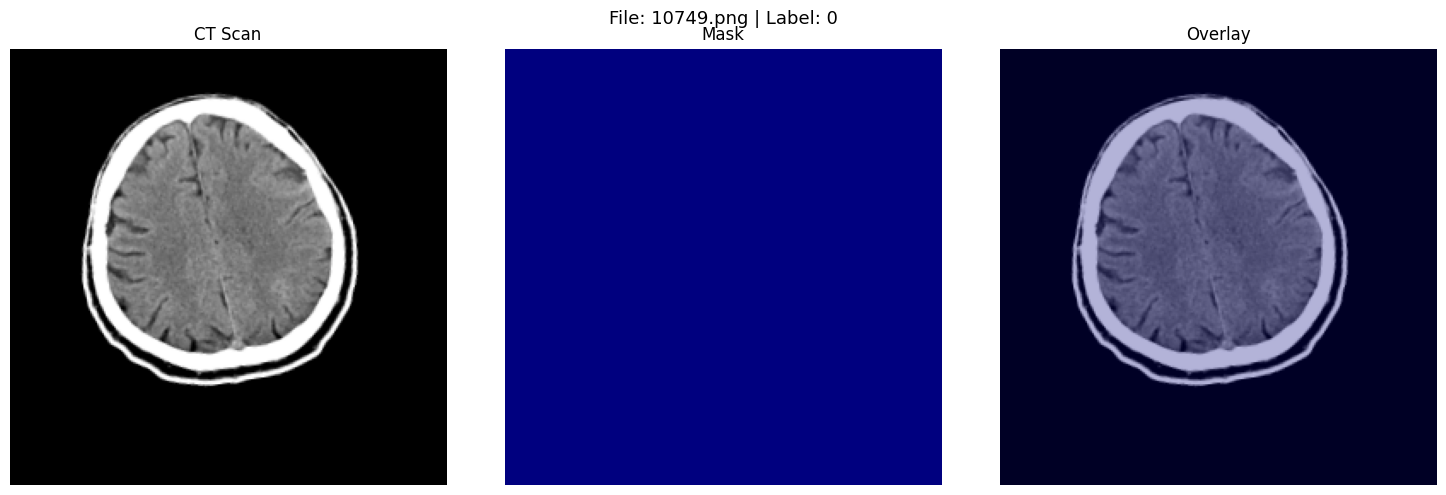

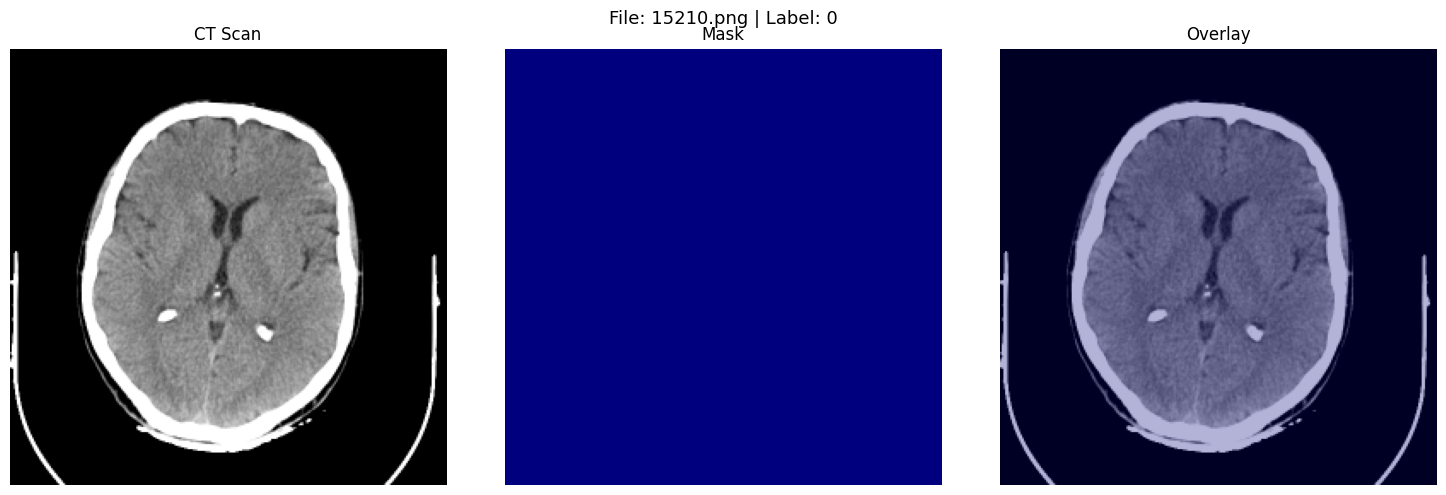

In [11]:
# ============================================================
# CELL 12: Build Splits & DataLoaders  ← CÓ CACHE
# ============================================================
if os.path.exists(CACHE_SPLITS):
    # ✅ Cache tồn tại → load ngay, không cần chạy lại
    print(f"[CACHE] Loading splits from {CACHE_SPLITS} ...")
    with open(CACHE_SPLITS, "rb") as f:
        cached       = pickle.load(f)
    train_data   = cached["train_data"]
    val_data     = cached["val_data"]
    test_data    = cached["test_data"]
    class_to_idx = cached["class_to_idx"]
    print(f"[CACHE] Loaded → Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
else:
    # 🔄 Chưa có cache → tạo mới rồi lưu
    print("[CACHE] Cache not found – preparing dataset ...")
    dataset, class_to_idx = prepare_dataset()
    labels_all = [d["label"] for d in dataset]
    train_data, test_data = train_test_split(
        dataset, test_size=0.2, stratify=labels_all, random_state=SEED)
    train_labels_split = [d["label"] for d in train_data]
    train_data, val_data = train_test_split(
        train_data, test_size=0.1, stratify=train_labels_split, random_state=SEED)

    with open(CACHE_SPLITS, "wb") as f:
        pickle.dump({"train_data": train_data, "val_data": val_data,
                     "test_data": test_data,   "class_to_idx": class_to_idx}, f)
    print(f"[CACHE] Saved to {CACHE_SPLITS}")
    print(f"Split → Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

# Weighted sampler
train_labels = [d["label"] for d in train_data]
class_counts = Counter(train_labels)
print("Class Distribution in Train:", dict(class_counts))
weights = [1.0 / class_counts[lbl] for lbl in train_labels]
sampler = WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)

# Datasets & DataLoaders
train_dataset = CTScanDataset(train_data, augment=True)
val_dataset   = CTScanDataset(val_data,   augment=False)
test_dataset  = CTScanDataset(test_data,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          pin_memory=True, num_workers=4,
                          persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          pin_memory=True, num_workers=4,
                          persistent_workers=True, prefetch_factor=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          pin_memory=True, num_workers=4,
                          persistent_workers=True, prefetch_factor=2)

visualize_dataset_sample(train_dataset, min(25, len(train_dataset)-1), "sample_train.png")
visualize_dataset_sample(test_dataset,  min(5,  len(test_dataset)-1),  "sample_test.png")

In [12]:
# ============================================================
# CELL 13: Model Definition
# ============================================================
def get_manet_model(num_classes=1, pretrained=True):
    model = smp.MAnet(
        encoder_name    = "resnet50",
        encoder_weights = "imagenet" if pretrained else None,
        in_channels     = 1,
        classes         = num_classes,
    )
    for param in model.encoder.parameters():
        param.requires_grad = False
    print("MANet initialized (encoder frozen for Stage 1).")
    return model

def load_best_model(path=BEST_MODEL_PATH):
    base_model = smp.MAnet(encoder_name="resnet50", encoder_weights=None,
                           in_channels=1, classes=1)
    state = torch.load(path, map_location=DEVICE, weights_only=False)
    # Xử lý trường hợp model được save qua DataParallel (key có prefix "module.")
    if any(k.startswith("module.") for k in state.keys()):
        state = {k.replace("module.", ""): v for k, v in state.items()}
    base_model.load_state_dict(state)
    print(f"Loaded best model from {path}")
    return base_model.to(DEVICE).eval()

In [13]:
# ============================================================
# CELL 14: Training Setup + RESUME từ checkpoint
# ============================================================
model   = get_manet_model(num_classes=1).to(DEVICE)
# Dùng 2 GPU T4 nếu có
if torch.cuda.device_count() > 1:
    print(f"Dùng {torch.cuda.device_count()} GPUs – bật DataParallel!")
    model = nn.DataParallel(model)
loss_fn = smp.losses.DiceLoss(mode="binary")

# Khởi tạo mặc định (Stage 1)
optimizer = optim.AdamW(model.parameters(), lr=LR_STAGE_1)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FROZEN_EPOCHS)

best_val_dice = 0.0
start_epoch   = 0
history = {"train_loss": [], "train_dice": [], "val_loss": [], "val_dice": []}

# Mixed Precision Training (PyTorch 2.x API)
scaler = torch.amp.GradScaler("cuda")

if os.path.exists(CHECKPOINT_PATH):
    print(f"\n[CHECKPOINT] Found {CHECKPOINT_PATH} – đang resume ...")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)

    state_dict = ckpt["model_state_dict"]
    # Tự động xử lý khớp prefix "module." để có thể resume trên mọi cấu hình GPU (1 GPU hoặc 2 GPU)
    curr_is_dp = isinstance(model, nn.DataParallel)
    ckpt_is_dp = any(k.startswith("module.") for k in state_dict.keys())
    
    if curr_is_dp and not ckpt_is_dp:
        # Resume từ 1 GPU sang 2 GPU: thêm prefix
        state_dict = {"module." + k: v for k, v in state_dict.items()}
    elif not curr_is_dp and ckpt_is_dp:
        # Resume từ 2 GPU sang 1 GPU: xóa prefix
        state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
        
    model.load_state_dict(state_dict)

    start_epoch   = ckpt["epoch"] + 1          # tiếp tục từ epoch kế tiếp
    best_val_dice = ckpt["best_val_dice"]
    history       = ckpt["history"]

    # Khôi phục đúng stage
    if start_epoch >= FROZEN_EPOCHS:
        print("[CHECKPOINT] Đã qua Stage 1 – mở khóa encoder cho Stage 2.")
        for param in model.parameters():
            param.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=LR_STAGE_2)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS - FROZEN_EPOCHS)

    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])

    print(f"[CHECKPOINT] Resume từ epoch {start_epoch}/{EPOCHS} | "
          f"Best Val Dice: {best_val_dice:.4f}")
else:
    print("[CHECKPOINT] Không có checkpoint – training từ đầu.")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

MANet initialized (encoder frozen for Stage 1).
Dùng 2 GPUs – bật DataParallel!
[CHECKPOINT] Không có checkpoint – training từ đầu.


In [14]:
# ============================================================
# CELL 15: Training Loop  ← CÓ CHECKPOINT MỖI EPOCH
# ============================================================
print(f"\n{'Epoch':<6} | {'Train Loss':<11} | {'Train Dice':<11} | {'Val Loss':<11} | {'Val Dice':<10} | LR")
print("-" * 82)

for epoch in range(start_epoch, EPOCHS):

    # Chuyển sang Stage 2 nếu đúng epoch
    if epoch == FROZEN_EPOCHS:
        print(f"\n[EPOCH {epoch+1}] Unfreezing all layers – Stage 2 bắt đầu.")
        for param in model.parameters():
            param.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=LR_STAGE_2)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS - FROZEN_EPOCHS)
        print(f"Optimizer reset với LR={LR_STAGE_2:.1e}\n")

    # --- Train ---
    model.train()
    train_loss_accum = train_dice_accum = 0.0

    for images, masks, _, _ in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.reshape(-1, 1, IMG_SIZE, IMG_SIZE).float().to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        
        with torch.amp.autocast("cuda"):
            logits = model(images)
            loss   = loss_fn(logits, masks)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss_accum += loss.item()
        preds = logits.sigmoid()
        tp, fp, fn, tn = smp.metrics.get_stats(preds, masks.long(), mode="binary", threshold=0.5)
        train_dice_accum += smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro-imagewise").item()

    avg_train_loss = train_loss_accum / len(train_loader)
    avg_train_dice = train_dice_accum / len(train_loader)

    # --- Validate ---
    model.eval()
    val_loss_accum = val_dice_accum = 0.0
    with torch.inference_mode():
        for images, masks, _, _ in val_loader:
            images = images.to(DEVICE, non_blocking=True)
            masks  = masks.reshape(-1, 1, IMG_SIZE, IMG_SIZE).float().to(DEVICE, non_blocking=True)
            
            with torch.amp.autocast("cuda"):
                logits = model(images)
                loss_val = loss_fn(logits, masks)
                
            val_loss_accum += loss_val.item()
            preds = logits.sigmoid()
            tp, fp, fn, tn = smp.metrics.get_stats(preds, masks.long(), mode="binary", threshold=0.5)
            val_dice_accum += smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro-imagewise").item()

    avg_val_loss = val_loss_accum / len(val_loader)
    avg_val_dice = val_dice_accum / len(val_loader)

    history["train_loss"].append(avg_train_loss)
    history["train_dice"].append(avg_train_dice)
    history["val_loss"].append(avg_val_loss)
    history["val_dice"].append(avg_val_dice)

    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    print(f"{epoch+1:<6} | {avg_train_loss:<11.4f} | {avg_train_dice:<11.4f} | "
          f"{avg_val_loss:<11.4f} | {avg_val_dice:<10.4f} | {current_lr:.2e}")

    # 💾 Lưu best model
    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  ✓ Best model saved (Val Dice: {best_val_dice:.4f})")

    # 💾 Lưu checkpoint đầy đủ sau mỗi epoch (để resume khi bị lỗi)
    torch.save({
        "epoch":                epoch,
        "model_state_dict":     model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_dice":        best_val_dice,
        "history":              history,
    }, CHECKPOINT_PATH)

print("-" * 82)
print(f"Training complete. Best Val Dice: {best_val_dice:.4f}")


Epoch  | Train Loss  | Train Dice  | Val Loss    | Val Dice   | LR
----------------------------------------------------------------------------------
1      | 0.9598      | 0.0733      | 0.9599      | 0.0705     | 1.00e-04
  ✓ Best model saved (Val Dice: 0.0705)
2      | 0.9370      | 0.1384      | 0.9394      | 0.2324     | 9.89e-05
  ✓ Best model saved (Val Dice: 0.2324)
3      | 0.9003      | 0.2470      | 0.8895      | 0.3947     | 9.57e-05
  ✓ Best model saved (Val Dice: 0.3947)
4      | 0.8140      | 0.3903      | 0.8083      | 0.5500     | 9.05e-05
  ✓ Best model saved (Val Dice: 0.5500)
5      | 0.6789      | 0.5027      | 0.6675      | 0.5767     | 8.35e-05
  ✓ Best model saved (Val Dice: 0.5767)
6      | 0.5500      | 0.5849      | 0.5624      | 0.6970     | 7.50e-05
  ✓ Best model saved (Val Dice: 0.6970)
7      | 0.4575      | 0.6221      | 0.4557      | 0.6750     | 6.55e-05
8      | 0.4049      | 0.6461      | 0.4053      | 0.7008     | 5.52e-05
  ✓ Best model saved (Val

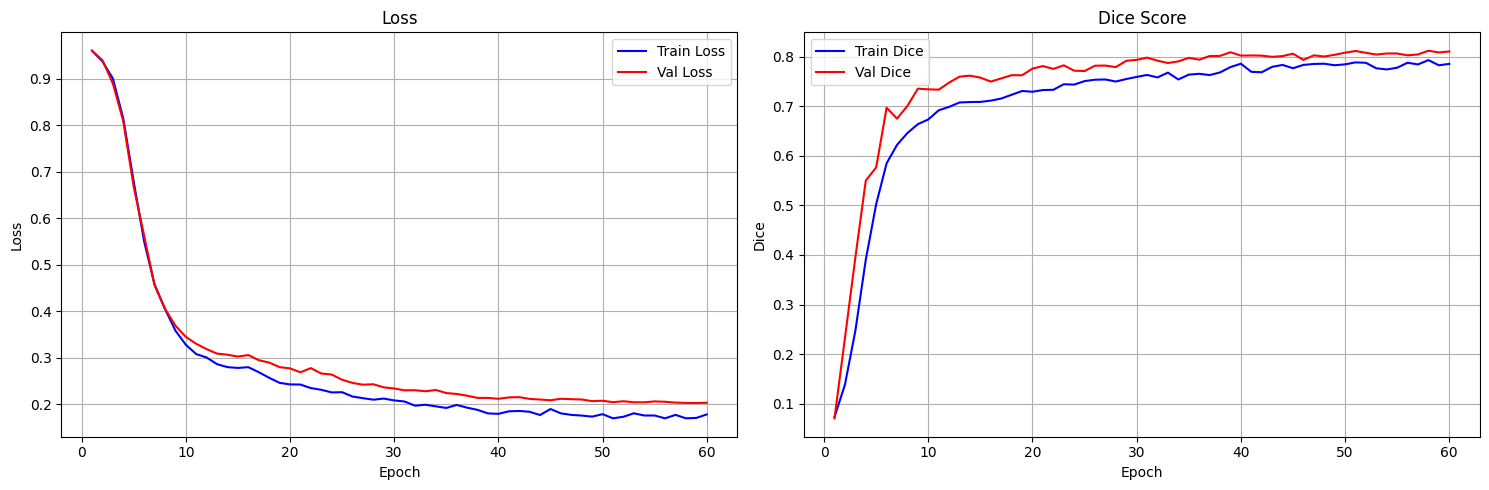

Saved: training_history.png


In [15]:
# ============================================================
# CELL 16: Training History Plot
# ============================================================
def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(epochs, history["train_loss"], "b-", label="Train Loss")
    ax1.plot(epochs, history["val_loss"],   "r-", label="Val Loss")
    ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(True)
    ax2.plot(epochs, history["train_dice"], "b-", label="Train Dice")
    ax2.plot(epochs, history["val_dice"],   "r-", label="Val Dice")
    ax2.set_title("Dice Score"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Dice")
    ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, "training_history.png"), dpi=100)
    plt.show()
    print("Saved: training_history.png")

if history["train_loss"]:
    plot_training_history(history)

Loaded best model from /kaggle/working/best_manet_model.pth


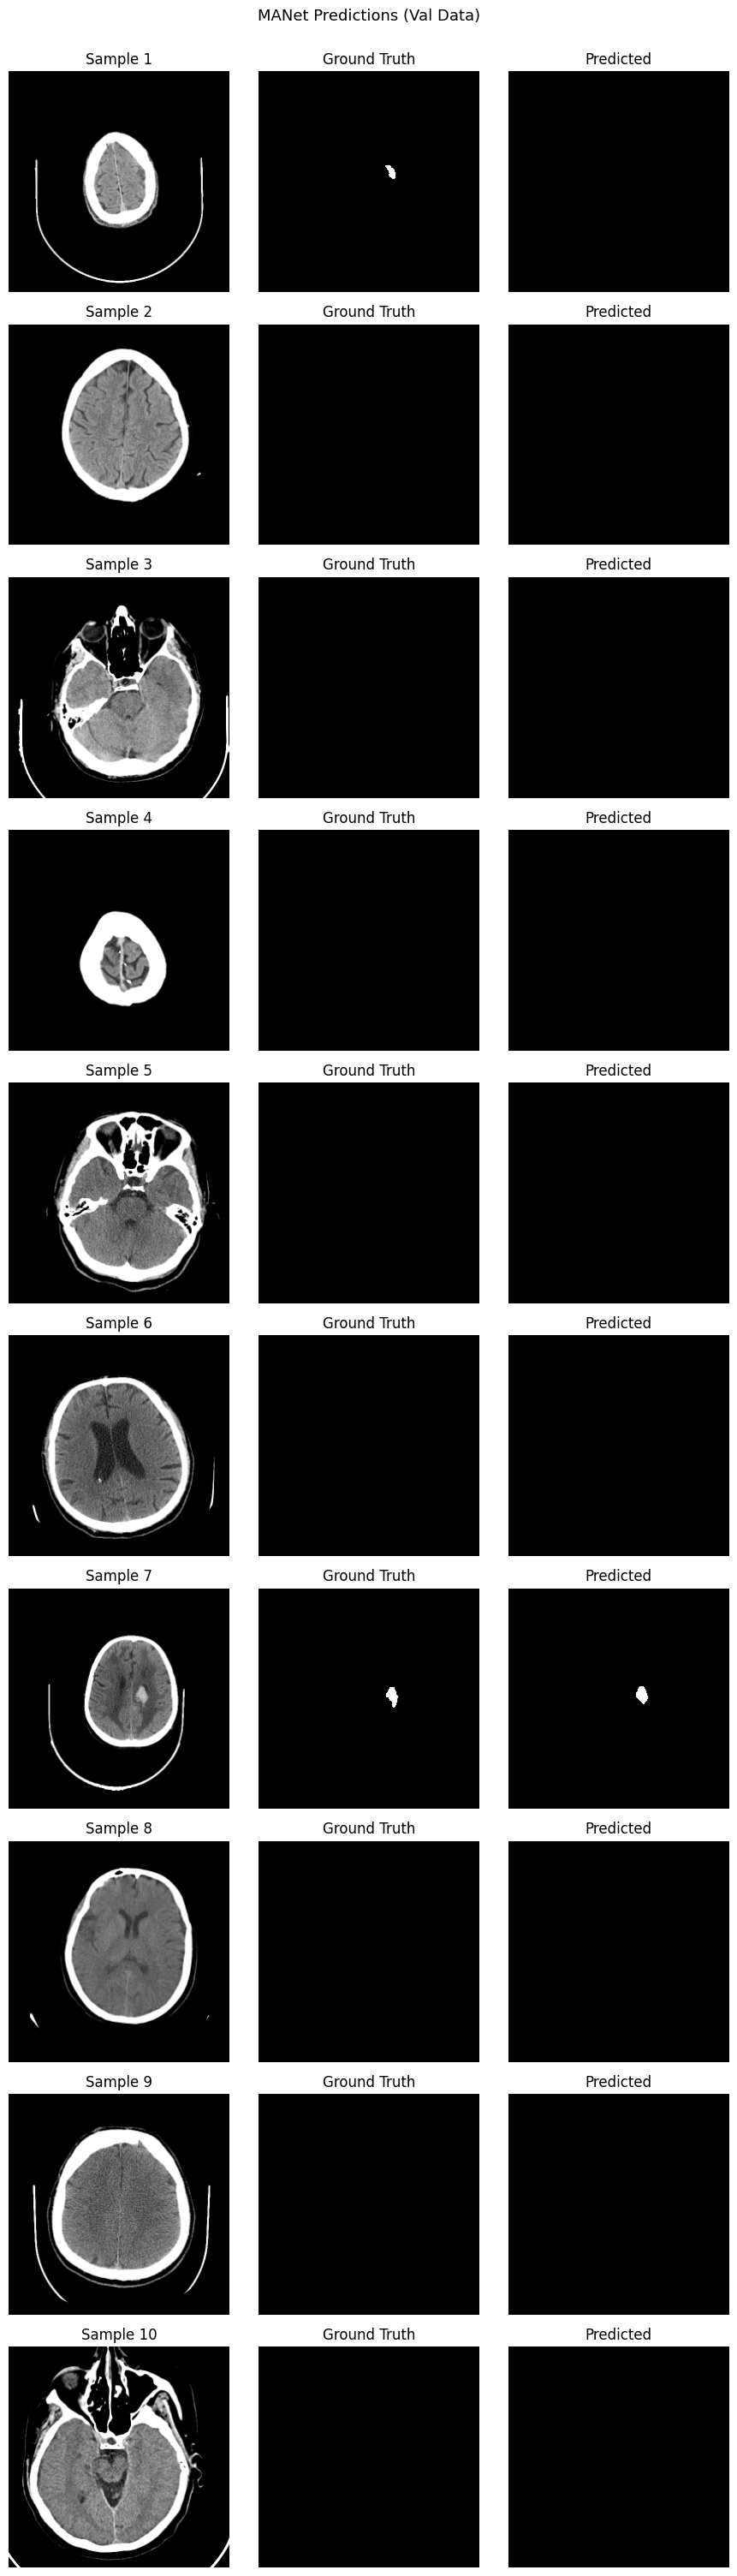

Saved: predictions_val.png


In [16]:
# ============================================================
# CELL 17: Load Best Model & Prediction Visualization
# ============================================================
best_model = load_best_model(BEST_MODEL_PATH)

def predict_and_visualize(model, dataset, num_samples=10, save_name="predictions_val.png"):
    num_samples = min(num_samples, len(dataset))
    fig, axes   = plt.subplots(num_samples, 3, figsize=(9, 3 * num_samples))
    plt.suptitle("MANet Predictions (Val Data)", y=1.001, fontsize=13)
    if num_samples == 1:
        axes = axes[np.newaxis, :]
    for i in range(num_samples):
        img_t, mask_t, _, _ = dataset[i]
        with torch.inference_mode():
            pred_mask = (model(img_t.unsqueeze(0).to(DEVICE)).sigmoid() > 0.5).cpu().squeeze().numpy()
        img_np  = img_t.permute(1, 2, 0).numpy()
        mask_np = mask_t.squeeze().numpy()
        axes[i, 0].imshow(img_np.squeeze(), cmap="gray"); axes[i, 0].set_title(f"Sample {i+1}"); axes[i, 0].axis("off")
        axes[i, 1].imshow(mask_np,          cmap="gray"); axes[i, 1].set_title("Ground Truth");  axes[i, 1].axis("off")
        axes[i, 2].imshow(pred_mask,         cmap="gray"); axes[i, 2].set_title("Predicted");     axes[i, 2].axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, save_name), dpi=100)
    plt.show()
    print(f"Saved: {save_name}")

predict_and_visualize(best_model, val_dataset)

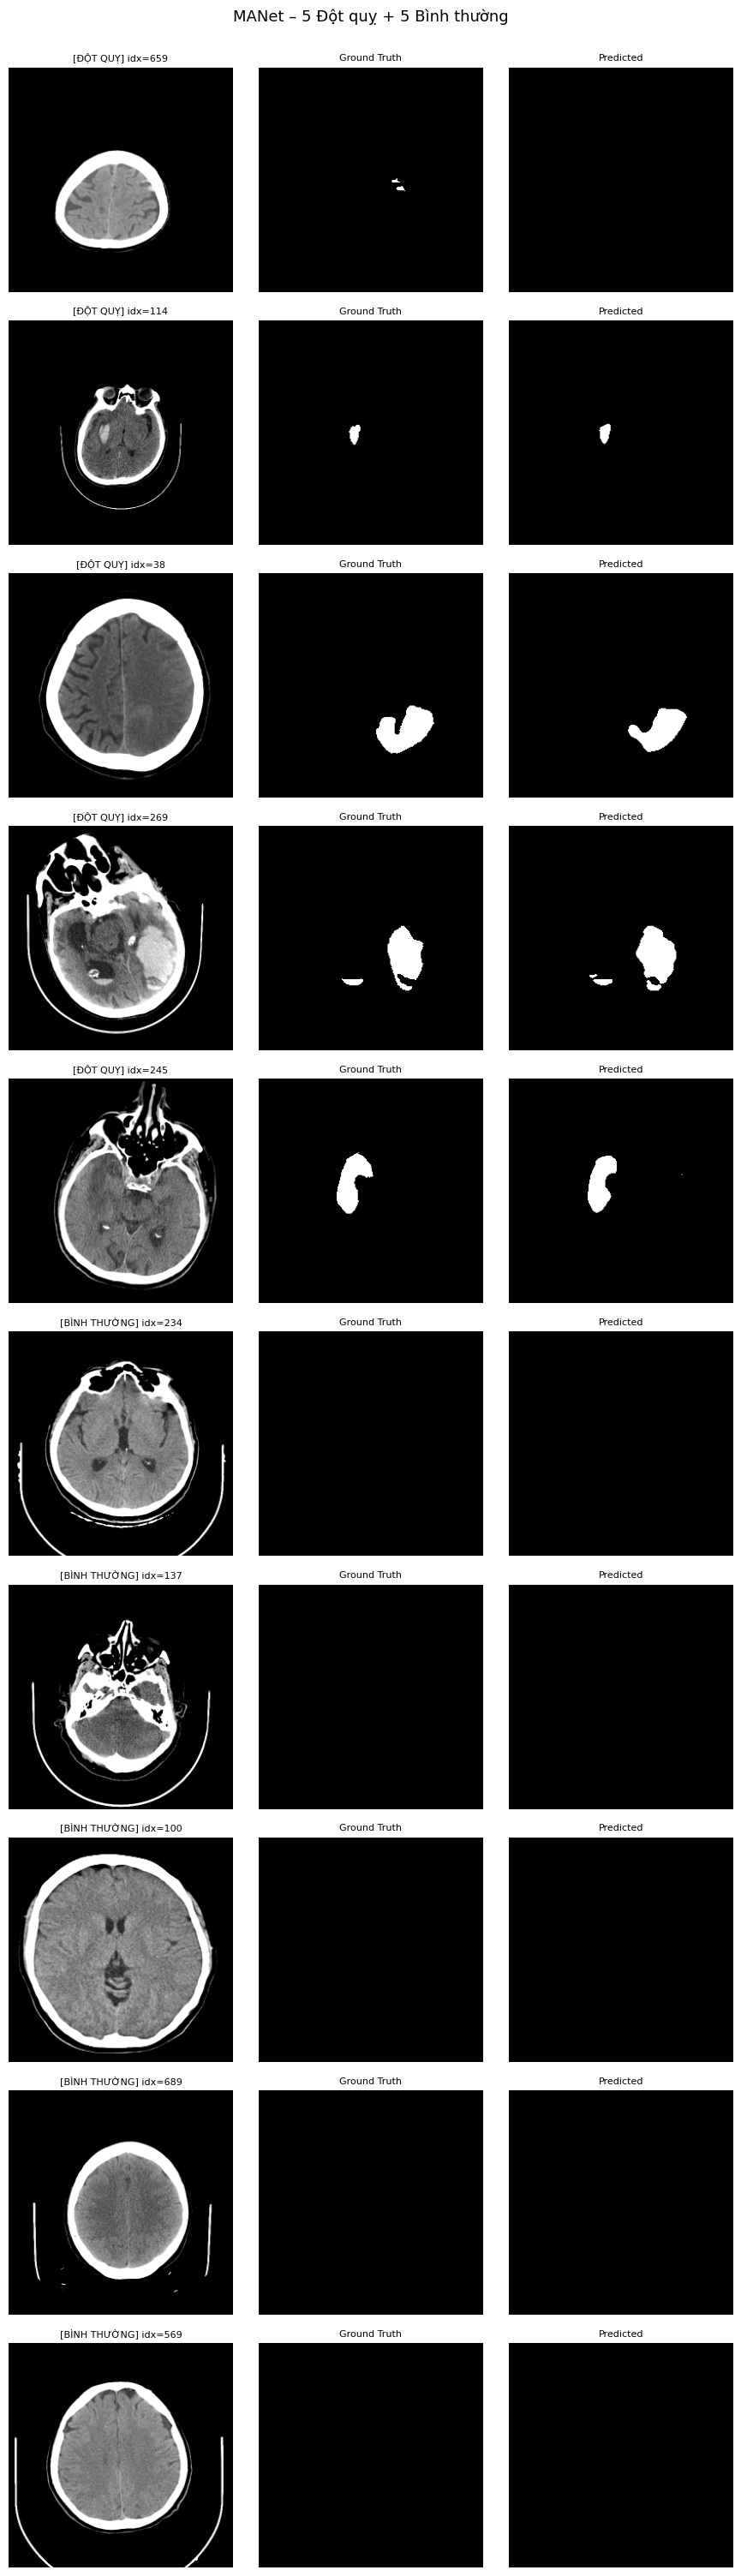

Saved: predictions_mixed.png


In [17]:
# ============================================================
# CELL 18: Mixed Visualization (Stroke vs Normal)
# ============================================================
def predict_and_visualize_mixed(model, dataset, n_each=5):
    stroke_idx = [i for i in range(len(dataset)) if dataset[i][2].item() > 0]
    normal_idx = [i for i in range(len(dataset)) if dataset[i][2].item() == 0]
    selected   = random.sample(stroke_idx, min(n_each, len(stroke_idx))) + \
                 random.sample(normal_idx, min(n_each, len(normal_idx)))
    n = len(selected)
    if n == 0:
        print("Không tìm thấy mẫu phù hợp để trực quan hóa.")
        return
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    plt.suptitle(f"MANet – {min(n_each,len(stroke_idx))} Đột quỵ + {min(n_each,len(normal_idx))} Bình thường",
                 y=1.001, fontsize=13)
    if n == 1:
        axes = axes[np.newaxis, :]
    for row, idx in enumerate(selected):
        img_t, mask_t, label, _ = dataset[idx]
        with torch.inference_mode():
            pred_mask = (model(img_t.unsqueeze(0).to(DEVICE)).sigmoid() > 0.5).cpu().squeeze().numpy()
        img_np  = img_t.permute(1, 2, 0).numpy()
        mask_np = mask_t.squeeze().numpy()
        status  = "ĐỘT QUỴ" if label.item() > 0 else "BÌNH THƯỜNG"
        axes[row, 0].imshow(img_np.squeeze(), cmap="gray")
        axes[row, 0].set_title(f"[{status}] idx={idx}", fontsize=8); axes[row, 0].axis("off")
        axes[row, 1].imshow(mask_np,  cmap="gray"); axes[row, 1].set_title("Ground Truth", fontsize=8); axes[row, 1].axis("off")
        axes[row, 2].imshow(pred_mask, cmap="gray"); axes[row, 2].set_title("Predicted",    fontsize=8); axes[row, 2].axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, "predictions_mixed.png"), dpi=100)
    plt.show()
    print("Saved: predictions_mixed.png")

predict_and_visualize_mixed(best_model, val_dataset)

Đang đánh giá trên tập Test...


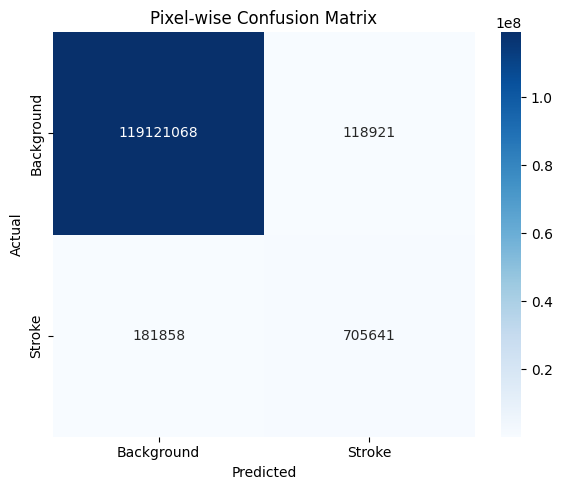

Saved: confusion_matrix.png
  BÁO CÁO ĐÁNH GIÁ TRÊN TẬP TEST
  Accuracy        : 0.9975
  Precision       : 0.8558
  Recall          : 0.7951
  F1-Score (Dice) : 0.8243
  IoU (Jaccard)   : 0.7011


In [18]:
# ============================================================
# CELL 19: Evaluation on Test Set
# ============================================================
# --- Đảm bảo best_model luôn tồn tại ---
if 'best_model' not in dir() or best_model is None:
    print("best_model chưa có – đang load từ checkpoint...")
    best_model = smp.MAnet(
        encoder_name    = "resnet50",
        encoder_weights = None,
        in_channels     = 1,
        classes         = 1,
    )
    state = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
    if any(k.startswith("module.") for k in state.keys()):
        state = {k.replace("module.", ""): v for k, v in state.items()}
    best_model.load_state_dict(state)
    best_model = best_model.to(DEVICE).eval()
    print(f"Loaded best model from {BEST_MODEL_PATH}")
def evaluate_on_test_set(model, loader):
    model.eval()
    tp_t = fp_t = fn_t = tn_t = 0
    with torch.inference_mode():
        for images, masks, _, _ in loader:
            images = images.to(DEVICE, non_blocking=True)
            masks  = masks.reshape(-1, 1, IMG_SIZE, IMG_SIZE).float().to(DEVICE, non_blocking=True)
            logits = model(images)
            preds  = logits.sigmoid()
            tp, fp, fn, tn = smp.metrics.get_stats(preds, masks.long(), mode="binary", threshold=0.5)
            tp_t += tp.sum().item(); fp_t += fp.sum().item()
            fn_t += fn.sum().item(); tn_t += tn.sum().item()
    return tp_t, fp_t, fn_t, tn_t

#
def plot_confusion_matrix_and_metrics(tp, fp, fn, tn):
    cm = np.array([[tn, fp], [fn, tp]])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Background", "Stroke"],
                yticklabels=["Background", "Stroke"])
    plt.title("Pixel-wise Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, "confusion_matrix.png"), dpi=100)
    plt.show()
    print("Saved: confusion_matrix.png")

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    iou       = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    accuracy  = (tp + tn) / (tp + fp + fn + tn)

    print("=" * 50)
    print("  BÁO CÁO ĐÁNH GIÁ TRÊN TẬP TEST")
    print("=" * 50)
    print(f"  Accuracy        : {accuracy:.4f}")
    print(f"  Precision       : {precision:.4f}")
    print(f"  Recall          : {recall:.4f}")
    print(f"  F1-Score (Dice) : {f1:.4f}")
    print(f"  IoU (Jaccard)   : {iou:.4f}")
    print("=" * 50)

print("Đang đánh giá trên tập Test...")
tp, fp, fn, tn = evaluate_on_test_set(best_model, test_loader)
plot_confusion_matrix_and_metrics(tp, fp, fn, tn)